# Business Understanding



Operation Blue Sentinel: ระบบตรวจจับเรือประมงผิดกฎหมายในน่านน้ำเอเชียตะวันออกเฉียงใต้

กรมประมงระหว่างประเทศ (Fictional Agency: SEAFISH-INT) ได้รับมอบหมายให้ออกแบบระบบ intelligence เพื่อระบุพฤติกรรมต้องสงสัยของเรือประมงในเขต EEZ ของ 5 ประเทศสมาชิก — ก่อนที่การละเมิดจะเกิดขึ้นหรือทวีความรุนแรง

โดยที่"SEAFISH-INT ต้องการทั้ง (1) รายงาน intelligence เชิงพื้นที่สำหรับทีมนโยบาย และ (2) ระบบ scoring อัตโนมัติสำหรับทีมปฏิบัติการ จาก data pipeline เดียวกัน"

# Pre: Data Understanding ก่อนทำการ Preparation

## import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## นำเข้าข้อมูล

In [ ]:
from google.colab import files
uploaded = files.upload()
uploaded.keys()

Saving 01_ais_vessel_tracking.csv to 01_ais_vessel_tracking (9).csv
Saving 02_sea_surface_temperature.csv to 02_sea_surface_temperature (9).csv
Saving 03_ocean_chlorophyll.csv to 03_ocean_chlorophyll (9).csv
Saving 04_eez_boundary_lookup.csv to 04_eez_boundary_lookup (9).csv


dict_keys(['01_ais_vessel_tracking (9).csv', '02_sea_surface_temperature (9).csv', '03_ocean_chlorophyll (9).csv', '04_eez_boundary_lookup (9).csv'])

In [ ]:
ais_tracking = pd.read_csv("data/01_ais_vessel_tracking.csv")
surface_temperature = pd.read_csv("data/02_sea_surface_temperature.csv")
chlorophyll = pd.read_csv("data/03_ocean_chlorophyll.csv")
boundary = pd.read_csv("data/04_eez_boundary_lookup.csv")

## AIS Tracking

Fact Table บันทึกพิกัดและการเคลื่อนที่ของเรือผ่านระบบสัญญาณ AIS โดยมี lable บอกพฤติกรรมที่น่าสงสัย

In [ ]:
ais_tracking.shape

(15862, 18)

In [ ]:
ais_tracking.head()

,vessel_id,mmsi,vessel_name,flag_state,vessel_type,length_m,gross_ton,timestamp,date,lat,lon,lat_grid,lon_grid,speed_knots,heading_deg,nav_status,ais_gap_hours,label_suspicious
0,VSL_0001,595822412,VESSEL_2412,VNM,Reefer,86,1688,2023-02-25 00:00:00,2023-02-25,4.5907,107.1797,4.50,107.25,8.80,93,Underway,0,0
1,VSL_0001,595822412,VESSEL_2412,VNM,Reefer,86,1688,2023-02-25 03:25:42,2023-02-25,4.6936,107.3576,4.75,107.25,5.69,236,Underway,0,0
2,VSL_0001,595822412,VESSEL_2412,VNM,Reefer,86,1688,2023-02-25 06:51:25,2023-02-25,4.3867,107.6770,4.50,107.75,9.33,38,Fishing,0,0
3,VSL_0001,595822412,VESSEL_2412,VNM,Reefer,86,1688,2023-02-25 10:17:08,2023-02-25,4.2370,108.0648,4.25,108.00,8.79,281,Underway,0,0
4,VSL_0001,595822412,VESSEL_2412,VNM,Reefer,86,1688,2023-02-25 13:42:51,2023-02-25,4.4729,108.0817,4.50,108.00,13.65,25,Underway,0,0


In [ ]:
# ดูประเภททั้งหมดใน columns ที่เป็น categories
column = ["flag_state", "vessel_type", "nav_status"]
for i in column:
  print(i)
  print(ais_tracking[i].unique())

flag_state
['VNM' 'MYS' 'THA' 'IDN' 'JPN' 'TWN' 'CHN' 'PAN' 'KOR' 'PHL']
vessel_type
['Reefer' 'Trawler' 'Longline' 'Purse_Seiner' 'Squid_Jigger' 'Carrier']
nav_status
['Underway' 'Fishing' 'Unknown' 'Moored']


ข้อมูลขนาด 15862 เเถว, 18 columns เป็นตารางหลัก

1. vessel_id/ mmsi/ vessel_name: รหัสเรือ/ รหัสสากล/ ชื่อเรือ

2. flag_state: สัญชาติเรือ

    VNM: เวียดนาม, MYS: มาเล, THA: ไทย, IDN: อินโด, JPN: ญี่ปุ่น, TWN: ไต้หวัน, CHN: จีน ,PAN: ปานามา, KOR: เกาหลีใต้, PHL: ฟิลิปปินส์

3. vessel_type: ประเภทเรือ
    
    Reefer เรือเย็นขนปลา,
    Trawler เรือใช้อวนลาก,
    Longline เรือเบ็ดราว, Purse_Seiner เรืออวนล้อมจับ,
    Squid_jigger เรือตกหมึก, Carrier เรือขนสินค้า

4. length_m/ gross_ton: ความยาวของเรือ (ม.)/ น้ำหนักรวม (ตัน)

5. timestamp/ date: วันและเวลาที่บันทึกข้อมูล

6. lat/ lon: ละติจูดและลองจิจูดของเรือ ณ เวลานั้น

7. lat_grid / lon_grid: พิกัดที่ถูกจัดกลุ่มเป็นกริด

8. speed_knots/ heading_deg: ความเร็ว (นอต)/ ทิศทางการเดินเรือ (องศา)

9. nav_status: สถานะของเรือ   

    Underway กำลังแล่น, Fishing กำลังทำประมง, Unknown ไม่รู้, Moored จอดเรือ

10. ais_gap_hours: ระยะเวลาที่สัญญาณ AIS หายไป (ชั่วโมง)

11. label_suspicious: บอกว่าเรือลำนี้น่าสงสัยทำผิดกฏหมายหรือปล่าว



In [ ]:
ais_tracking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15862 entries, 0 to 15861
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   vessel_id         15862 non-null  object 
 1   mmsi              15862 non-null  int64  
 2   vessel_name       15862 non-null  object 
 3   flag_state        15862 non-null  object 
 4   vessel_type       15862 non-null  object 
 5   length_m          15862 non-null  int64  
 6   gross_ton         15862 non-null  int64  
 7   timestamp         15862 non-null  object 
 8   date              15862 non-null  object 
 9   lat               15862 non-null  float64
 10  lon               15862 non-null  float64
 11  lat_grid          15862 non-null  float64
 12  lon_grid          15862 non-null  float64
 13  speed_knots       15862 non-null  float64
 14  heading_deg       15862 non-null  int64  
 15  nav_status        15862 non-null  object 
 16  ais_gap_hours     15862 non-null  int64 

In [ ]:
ais_tracking.duplicated().sum()

np.int64(0)

In [ ]:
ais_tracking.describe()

,mmsi,length_m,gross_ton,lat,lon,lat_grid,lon_grid,speed_knots,heading_deg,ais_gap_hours,label_suspicious
count,1.586200e+04,15862.000000,15862.000000,15862.000000,15862.000000,15862.000000,15862.000000,15862.000000,15862.000000,15862.000000,15862.000000
mean,5.511089e+08,63.127853,1632.173118,10.702990,108.072428,10.703300,108.073083,7.936434,179.539024,0.074896,0.090279
std,2.613400e+07,29.478267,839.736820,6.370679,7.168803,6.371463,7.169256,2.996219,104.494033,0.841181,0.286590
min,5.108722e+08,16.000000,251.000000,0.000000,95.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000
25%,5.267539e+08,46.000000,696.000000,4.623175,101.838000,4.500000,101.750000,6.140000,89.000000,0.000000,0.000000
50%,5.472953e+08,61.000000,1732.000000,10.757150,108.152300,10.750000,108.250000,8.150000,179.000000,0.000000,0.000000
75%,5.716630e+08,86.000000,2386.000000,16.686025,114.240675,16.750000,114.250000,10.000000,270.000000,0.000000,0.000000
max,5.972260e+08,117.000000,2903.000000,22.000000,122.000000,22.000000,122.000000,19.700000,359.000000,12.000000,1.000000


In [ ]:
ais_tracking.describe(include= "object")

,vessel_id,vessel_name,flag_state,vessel_type,timestamp,date,nav_status
count,15862,15862,15862,15862,15862,15862,15862
unique,60,60,10,6,9287,347,4
top,VSL_0007,VESSEL_8463,VNM,Trawler,2023-09-13 00:00:00,2023-07-24,Underway
freq,644,644,4102,6042,11,96,10833


*   ข้อมูลไม่มีค่าว่างไม่มีการบันทึก record ซ้ำ
*   เรือมีทั้งหมด 60 ลำ เเต่ละลำถูกบันทึก 644 รอบจาก 10 ประเทศ
*   ดูสถิติเบื้องต้นไม่มีค่าผิดปกติ เช่น ค่าที่ไม่ควรติดลบ หรือ มากเกินจริง





## Sea_surface_temperature

ข้อมูลสภาพแวดล้อมที่วัดค่าอุณหภูมิของผิวน้ำทะเลในแต่ละพื้นที่และเวลาจากดาวเทียม

In [ ]:
surface_temperature.shape

(13555, 7)

In [ ]:
surface_temperature.head()

,lat_grid,lon_grid,date,sst_celsius,sst_anomaly,quality_flag,data_source
0,0.0,117.0,2023-01-01,23.67,-0.434,1,MODIS_AQUA
1,1.0,99.0,2023-01-01,23.69,-0.716,1,MODIS_AQUA
2,1.0,107.0,2023-01-01,23.72,-0.690,1,MODIS_AQUA
3,2.0,97.0,2023-01-01,24.40,-0.309,1,MODIS_AQUA
4,2.0,98.0,2023-01-01,24.61,-0.094,1,MODIS_AQUA


In [ ]:
print(surface_temperature["data_source"].unique())
surface_temperature["quality_flag"].unique()

['MODIS_AQUA']


array([1, 2])

ข้อมูลขนาด 13555 เเถว, 7 columns

1. lat_grid/ lon_grid/ date: พิกัดกริด/ วันที่

2. sst_celsius: อุณหภูมิผิวน้ำทะเล (เซลเซียส)

3. sst_anomaly: ค่าความผิดปกติของอุณหภูมิ (เทียบกับค่าเฉลี่ย)

4. quality_flag/ data_source: บอกคุณภาพของข้อมูล (1 คือดีมาก  2 ดีเเต่ไม่มาก) /แหล่งที่มา(ดาวเทียม)

In [ ]:
surface_temperature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13555 entries, 0 to 13554
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lat_grid      13555 non-null  float64
 1   lon_grid      13555 non-null  float64
 2   date          13555 non-null  object 
 3   sst_celsius   13555 non-null  float64
 4   sst_anomaly   13555 non-null  float64
 5   quality_flag  13555 non-null  int64  
 6   data_source   13555 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 741.4+ KB


In [ ]:
surface_temperature.duplicated().sum()

np.int64(0)

In [ ]:
surface_temperature.describe()

,lat_grid,lon_grid,sst_celsius,sst_anomaly,quality_flag
count,13555.000000,13555.000000,13555.000000,13555.000000,13555.000000
mean,10.681686,108.084157,26.362505,0.021697,1.257174
std,6.347823,7.266422,1.305096,0.501179,0.437093
min,0.000000,95.000000,22.110000,-1.811000,1.000000
25%,4.750000,101.750000,25.440000,-0.323000,1.000000
50%,10.750000,108.250000,26.340000,0.028000,1.000000
75%,16.500000,114.250000,27.330000,0.367000,2.000000
max,22.000000,122.000000,30.300000,1.775000,2.000000


- ข้อมูลไม่มีค่าว่างไม่มีการบันทึก record ซ้ำ
- ข้อมูลทั้งหมดมาจากดาวเทียม MODIS_AQUA
- ไม่มีค่าว่างเลยสัก record เเต่ต้องดูกับ quality_flag ด้วยเพราะบางทีเก็บมาได้เเต่ไม่ดี เเต่อันนี้มีเเค่สอง level คือ 1 กับ 2 (ปกติมีถึง 4 ไล่จาก 0-4 เพราะงั้นอาจจะดูอีกทีว่าข้อมูลของ level 2 เยอะเเค่ไหน ถ้าไม่มากอาจจะตัดทิ้งได้)
- ดูสถิติเบื้องต้นไม่มีค่าผิดปกติ เช่น ค่าที่ไม่ควรติดลบ หรือ มากเกินจริง

## Ocean_chlorophyll

ข้อมูลสภาพแวดล้อมบอกความอุดมสมบูรณ์ของแพลงก์ตอนพืช (คลอโรฟิลล์) ที่เป็นแหล่งอาหารหลักของสัตว์น้ำ เรือประมงมักจะไปรวมตัวกันในบริเวณที่มีค่านี้สูงเพระามีอะไรให้ตก

In [ ]:
chlorophyll.shape

(13555, 8)

In [ ]:
chlorophyll.head()

,lat_grid,lon_grid,date,chlorophyll_mg_m3,ndci,cloud_cover_frac,pixel_valid,data_source
0,0.0,117.0,2023-01-01,1.9245,0.5875,0.42,1,MODIS_TERRA
1,1.0,99.0,2023-01-01,2.1635,0.6246,0.35,1,MODIS_TERRA
2,1.0,107.0,2023-01-01,1.4229,0.4800,0.63,0,MODIS_TERRA
3,2.0,97.0,2023-01-01,1.8652,0.5772,0.19,1,MODIS_TERRA
4,2.0,98.0,2023-01-01,1.9879,0.5981,0.17,1,MODIS_TERRA


In [ ]:
print(chlorophyll["pixel_valid"].unique())
chlorophyll["data_source"].unique()

[1 0]


array(['MODIS_TERRA'], dtype=object)

ข้อมูลขนาด 13555 เเถว, 8 columns

1. lat_grid/ lon_grid/ date: พิกัดกริด/ วันที่

2. chlorophyll_mg_m3: ปริมาณคลอโรฟิลล์ (มิลลิกรัม/ลูกบาศก์เมตร) ยิ่งมากหมายถึงยิ่งอุดมสมบูรณ์

3. ndci: Normalized Difference Chlorophyll Index ใช้ติดตามตรวจสอบปรากฏการณ์น้ำทะเลเปลี่ยนสี

4. cloud_cover_frac/ pixel_valid: สัดส่วนของเมฆที่ปกคลุมตอนดาวเทียมถ่ายภาพ และความสมบูรณ์ของพิกเซล(1 ข้อมูลสมบูรณ์ ใช้งานได้ 0 ใช้งานไม่ได้)

3. data_source: แหล่งที่มา

In [ ]:
chlorophyll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13555 entries, 0 to 13554
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lat_grid           13555 non-null  float64
 1   lon_grid           13555 non-null  float64
 2   date               13555 non-null  object 
 3   chlorophyll_mg_m3  13555 non-null  float64
 4   ndci               13555 non-null  float64
 5   cloud_cover_frac   13555 non-null  float64
 6   pixel_valid        13555 non-null  int64  
 7   data_source        13555 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 847.3+ KB


In [ ]:
chlorophyll.duplicated().sum()

np.int64(0)

In [ ]:
chlorophyll.iloc[:, :-2].describe()

,lat_grid,lon_grid,chlorophyll_mg_m3,ndci,cloud_cover_frac
count,13555.000000,13555.000000,13555.000000,13555.000000,13555.000000
mean,10.681686,108.084157,2.152153,0.601822,0.399495
std,6.347823,7.266422,0.604757,0.096344,0.230237
min,0.000000,95.000000,0.698500,0.165600,0.000000
25%,4.750000,101.750000,1.715700,0.548700,0.200000
50%,10.750000,108.250000,2.074700,0.611600,0.400000
75%,16.500000,114.250000,2.601800,0.677600,0.600000
max,22.000000,122.000000,3.970300,0.776300,0.800000


- ข้อมูลไม่มีค่าว่างไม่มีการบันทึก record ซ้ำ
- ข้อมูลทั้งหมดมาจาก MODIS_TERRA
- ไม่มีค่าว่างเลยสัก record เเต่ต้องดูกับ pixel_valid ถ้า 1 คือใช้ได้ 0 ใช้ไม่ได้ต้องตัดทิ้ง
- ดูสถิติเบื้องต้นไม่มีค่าผิดปกติ เช่น ค่าที่ไม่ควรติดลบ หรือ มากเกินจริง

## Eez_boundary_lookup

เป็นตารางอ้างอิง (Dimension Table) แบบคงที่ เอาไว้ดูว่าพิกัดกริดนั้นๆ อยู่ในน่านน้ำของใคร หรือเป็นพื้นที่พิพาทไหม

In [ ]:
boundary.shape

(9701, 7)

In [ ]:
boundary.head()

,lat_grid,lon_grid,country_code,eez_name,zone_type,dist_to_border_nm,is_disputed
0,0.0,95.00,IDN,Indonesia_EEZ,EEZ,31.54,0
1,0.0,95.25,IDN,Indonesia_EEZ,EEZ,30.14,0
2,0.0,95.50,IDN,Indonesia_EEZ,EEZ,46.38,0
3,0.0,95.75,IDN,Indonesia_EEZ,EEZ,11.57,0
4,0.0,96.00,IDN,Indonesia_EEZ,EEZ,10.34,0


In [ ]:
column = ["country_code", "eez_name", "zone_type", "is_disputed"]
for i in column:
  print(i)
  print(boundary[i].unique())

country_code
['IDN' 'MYS' 'THA' 'INTL' 'PHL' 'VNM' 'CHN']
eez_name
['Indonesia_EEZ' 'Malaysia_EEZ' 'Thailand_EEZ' 'High_Seas'
 'Philippines_EEZ' 'Vietnam_EEZ' 'China_SCS_Claim']
zone_type
['EEZ' 'HIGH_SEAS' 'DISPUTED']
is_disputed
[0 1]


ข้อมูลขนาด 9701 เเถว, 7 columns เป็นตาราง Dim

1. lat_grid/ lon_grid: พิกัดกริด

2. country_code/ eez_name: รหัสประเทศและชื่อ เช่น INTL: นานาชาติ/
เขตเศรษฐกิจจำเพาะ (Exclusive Economic Zone) เช่น high seas: ทะเลหลวง

3. zone_type: ประเภทของพื้นที่
    
    EEZ: เขตเศรษฐกิจจำเพาะ
    DISPUTED: พื้นที่พิพาท/ทับซ้อน
    HIGH_SEAS: เขตทะเลหลวง

4. dist_to_border_nm: ระยะทางจากพิกัดนั้นถึงเส้นขอบชายแดน (ไมล์ทะเล)

5. is_disputed: บอกสถานะ (0 = พื้นที่ปกติ, 1 = พื้นที่พิพาท) เรือบางลำอาจอาศัยพื้นที่พิพาทในการหลีกเลี่ยงกฎหมาย เนื่องจากความไม่ชัดเจนของเส้นเขตแดน ทำให้เจ้าหน้าที่ของทั้งสองฝ่ายยากจะเข้าจับกุมหรือบังคับใช้กฎหมายได้เต็มที่

In [ ]:
boundary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9701 entries, 0 to 9700
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lat_grid           9701 non-null   float64
 1   lon_grid           9701 non-null   float64
 2   country_code       9701 non-null   object 
 3   eez_name           9701 non-null   object 
 4   zone_type          9701 non-null   object 
 5   dist_to_border_nm  9701 non-null   float64
 6   is_disputed        9701 non-null   int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 530.7+ KB


In [ ]:
boundary.duplicated().sum()

np.int64(0)

In [ ]:
boundary.iloc[:, :-1].describe()

,lat_grid,lon_grid,dist_to_border_nm
count,9701.000000,9701.000000,9701.000000
mean,11.000000,108.500000,25.429591
std,6.422947,7.866472,14.291533
min,0.000000,95.000000,0.500000
25%,5.500000,101.750000,13.070000
50%,11.000000,108.500000,25.520000
75%,16.500000,115.250000,37.680000
max,22.000000,122.000000,49.990000


- ข้อมูลไม่มีค่าว่างไม่มีการบันทึก record ซ้ำ
- มี 7 ประเทศอ้างอิงเเละ 7 เขตเศรษฐกิจจำเพาะ
- ดูสถิติเบื้องต้นไม่มีค่าผิดปกติ เช่น ค่าที่ไม่ควรติดลบ หรือ มากเกินจริง

# Data Preparation

## ตรวจสอบข้อมูลก่อน join

- เนื่องจากการ join ครั้งนี้มีการใช้ composite key ดังนั้นจึงต้องตรวจสอบ columns ที่เกี่ยวข้องให้ตรงกับเพื่อให้ join ติด
- การจัดการกับข้อมูลบางส่วนที่ไม่ผ่านเกณฑ์เพื่อให้ไม่มีข้อมูลขยะ
- รวมทั้งข้อมูลที่นำมา join ต้องไม่มีการซ้ำกัน ซึ่งเราตรวจเเล้วว่าทุก table ไม่มีค่าซ้ำเลย

### AIS_Tracking

#### ตรวจ columns ที่ใช้เป็น key

ตารางนี่เป็นตารางหลักที่ใช้ในการ join เป็น master table โดยจาการตรวจสอบเบื้องต้น ไม่มีเเถวซ้ำสามารถนำไป join ได้เลยโดย column ที่ทำหน้าที่เป็น key คือ

1. date
2. lat_grid
3. long_grid

เพราะฉนั้นเราจะทำการตรวจสอบ format ให้ตารางอื่น ๆ ตรงกับตารางนี้

In [ ]:
ais_tracking[["date", 'lat_grid', 'lon_grid']].sample(5)

,date,lat_grid,lon_grid
2774,2023-08-10,11.50,118.25
1798,2023-09-14,5.00,102.50
14824,2023-08-29,19.50,116.00
4882,2023-03-03,18.75,100.25
9045,2023-08-25,1.50,115.25


เนื่องจาก lat_grid, long_grid มีทั้งทศนิยม 1 เเละ 2 ตำเเหน่งดังนั้นเราจะทำให้เป็นสองตำเเหน่งทั้งหมดเพื่อให้ format เหมือนกันง่ายต่อการจัดการ table อื่น ๆ

In [ ]:
ais_tracking['lat_grid'].round(2)
ais_tracking['lon_grid'].round(2)
ais_tracking[["date", 'lat_grid', 'lon_grid']].sample(5)

,date,lat_grid,lon_grid
11374,2023-06-01,17.00,120.25
2835,2023-08-17,11.75,121.25
15022,2023-07-01,4.00,101.00
5698,2023-02-21,8.00,113.50
3216,2023-08-20,15.00,115.25


จากการดูรูปเเบบ
1. date = YYYY/MM/DD โดยที่เป็นปีคริส type object
2. lat_grid = ทศนิยมสองตำเเหน่ง
3. lon_grid = ทศนิยมสองตำเเหน่ง

### Sea_surface_temp


#### สำรวจข้อมูลจาก quality_flag

เนื่องจาก quality_flag บอกเราได้ว่าข้อมูลมีคุณภาพหรือไม่(มีตั้งเเต่ 0-4| 0 คือดีมาก ข้อมูลเรามี 1 เเละ 2) ดังนั้นเราจะดูสัดส่วยของข้อมูลที่ ถ้า level เป็น 2(คือข้อมูลเริ่มอาจไม่เเม่นยำเนื่องจากมีเมฆบังหรือเเสงไม่ดี)ไม่เยอะมากอาจสามารถตัดทิ้งได้

In [ ]:
# ดูจำนวนเเละสัดส่วนของข้อมูล
print(surface_temperature["quality_flag"].value_counts())
ratio = (surface_temperature["quality_flag"].value_counts()/surface_temperature["quality_flag"].count()) * 100
ratio

quality_flag
1    10069
2     3486
Name: count, dtype: int64


,count
quality_flag,
1,74.282553
2,25.717447


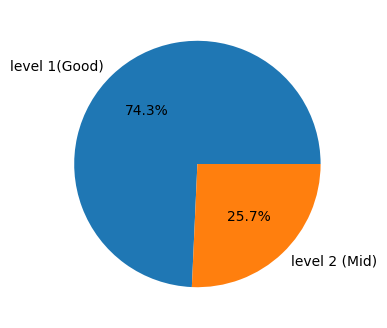

In [ ]:
# สร้าง pie chart ดูสัดส่วนง่าย ๆ
plt.figure(figsize= (4,4))
plt.pie(ratio, labels = ["level 1(Good)","level 2 (Mid)"], autopct='%1.1f%%')
plt.show()

จากสัดส่วนข้อมูล level 2 มีอยู่ 25% จากทั้งหมดซึ่งเยอะเกินไปที่จะตัดออก ข้อมูลเราจะเหลือน้อยเกิน ดังนั้นเก็บไว้

#### ตรวจ columns ที่ใช้เป็น key

ทำการปัดเศษ key lat_grid, lon_grid

In [ ]:
surface_temperature["lat_grid"].round(2)
surface_temperature["lon_grid"].round(2)
surface_temperature[["date", 'lat_grid', 'lon_grid']].sample(5)

,date,lat_grid,lon_grid
11542,2023-10-18,2.0,119.25
13040,2023-12-03,1.0,103.00
1944,2023-03-06,17.0,110.50
11913,2023-10-26,0.0,113.25
626,2023-01-28,22.0,107.00


columns ทั้งสามเป็น format เดียวกับ fact table

### Ocean_chlorophyll


#### จัดการข้อมูลจาก pixcel_valid

เนื่องจากpixel_valid คือค่า boolean ที่บอกว่าถ้าเป็น 1 คือใช้ได้เเต่เป็น 0 คือไม่ได้ ดังนั้นอันนี้ต้องตัด 100% ไม่งั้นจะเป็นข้อมูลขยะ

In [ ]:
chlorophyll.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13555 entries, 0 to 13554
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lat_grid           13555 non-null  float64
 1   lon_grid           13555 non-null  float64
 2   date               13555 non-null  object 
 3   chlorophyll_mg_m3  13555 non-null  float64
 4   ndci               13555 non-null  float64
 5   cloud_cover_frac   13555 non-null  float64
 6   pixel_valid        13555 non-null  int64  
 7   data_source        13555 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 847.3+ KB


In [ ]:
chlorophyll["pixel_valid"].value_counts()

,count
pixel_valid,
1,8416
0,5139


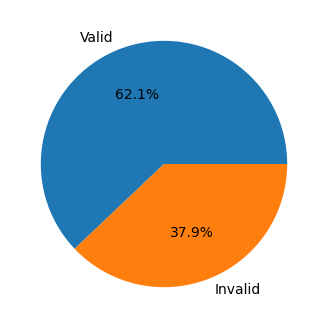

In [ ]:
plt.figure(figsize= (4,4))
size = (chlorophyll["pixel_valid"].value_counts()/ chlorophyll["pixel_valid"].count()) * 100
plt.pie(size, labels = ["Valid", "Invalid"], autopct="%1.1f%%")
plt.show()

เเม้สัดส่วนจะเยอะมากเเต่ต้องตัดเพราะมันเหมือนดาวเทียมถ่ายเเล้วไม่เห็นมั้ยเมฆบังเยอะเกิน

In [ ]:
chlorophyll_1 = chlorophyll[chlorophyll["pixel_valid"] == 1]
print(chlorophyll_1.shape)
chlorophyll_1["pixel_valid"].unique()

(8416, 8)


array([1])

ตอนนี้ข้อมูลเหลือ 8416 เเถวที่สามารถใช้งานได้

#### จัดการข้อมูลจาก cloud_cover_frac

columns ที่บอกเราว่าเมฆบังเยอะมั้ย เราสำรวจดูก่อนว่าข้อมูลที่เรามีตอนนี้ที่ผ่านการ valid เเล้วนั้นมีเมฆบังเยอะเเค่ไหน เพราะถ้าเยอะมากค่าก็เพี้ยน

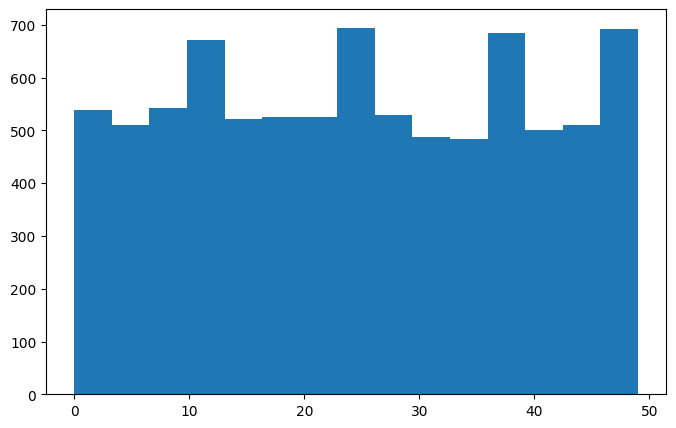

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(chlorophyll_1["cloud_cover_frac"]*100, bins= 15)
plt.show()

เมฆปกคลุมส่วนใหญ่อยู่ที่ 25% เเละไม่เกิน 50% ซึ่งถือว่าใช้ได้ไม่ต้องตัดทิ้ง

#### ตรวจ columns ที่ใช่เป็น key

ทำการปัดเศษ key lat_grid, lon_grid

In [ ]:
chlorophyll_1["lat_grid"].round(2)
chlorophyll_1["lon_grid"].round(2)
chlorophyll_1[["date", 'lat_grid', 'lon_grid']].sample(5)

,date,lat_grid,lon_grid
7182,2023-07-27,21.75,110.25
3649,2023-04-15,2.00,100.00
10063,2023-09-24,2.25,107.50
6501,2023-07-16,7.00,117.00
8211,2023-08-14,12.00,121.75


### Eez_boundary_lookup

#### ตรวจ columns ที่ใช่เป็น key

ทำการปัดเศษ key lat_grid, lon_grid

In [ ]:
boundary["lat_grid"].round(2)
boundary["lon_grid"].round(2)
boundary[['lat_grid', 'lon_grid']].sample(5)

,lat_grid,lon_grid
1407,3.00,119.75
4938,11.25,103.25
5153,11.75,102.50
7565,17.25,106.00
2111,4.75,105.00


**table นี้ไม่มีcolumn date เเต่ไม่เเปลกเพราะเป็น Dimtable ที่เป็นข้อมูลคงที่เป็นข้อมูลอ้างอิงเฉย ๆ ไม่ได้เปลี่ยนตามวันที่ ดังนั้นจะเชื่อมกับ key 2 ตัวคือ lat_grid, lon_grid**

## Join ข้อมูลเข้าด้วยกัน

เราจะใช้การ left join เข้า Fact table หรือตาราง AIS ที่เป็นตารางหลัก

- ที่ใช้ left join เนื่องจากข้อมูลของ AIS เป็นข้อมูลเเบบ transaction ที่เราจะคงไว้ซึ่งรูปเเบบของมัน ดังนั้นหากตารางอื่น ๆ ไม่มี key ตรงตาม AIS จะเป็นค่า null เเทนที่จะตัดเเถวนั้นทิ้ง ดังนั้นข้อมูลจะมีครบ 15862 เเถว
- ใข้ composite key ที่เราเตรียมไว้

In [ ]:
# left join surface_temp
all_data = pd.merge(left= ais_tracking, right= surface_temperature, on=["date", "lat_grid", "lon_grid"], how='left')
# left join chlorophyll
all_data = pd.merge(left= all_data, right= chlorophyll_1, on=["date", "lat_grid", "lon_grid"], how='left')
# left join boundary
all_data = pd.merge(left= all_data, right= boundary, on=["lat_grid", "lon_grid"], how='left')

In [ ]:
# ตรวจสอบว่าเชื่อมกันติดมั้ย
all_data.columns

Index(['vessel_id', 'mmsi', 'vessel_name', 'flag_state', 'vessel_type',
       'length_m', 'gross_ton', 'timestamp', 'date', 'lat', 'lon', 'lat_grid',
       'lon_grid', 'speed_knots', 'heading_deg', 'nav_status', 'ais_gap_hours',
       'label_suspicious', 'sst_celsius', 'sst_anomaly', 'quality_flag',
       'data_source_x', 'chlorophyll_mg_m3', 'ndci', 'cloud_cover_frac',
       'pixel_valid', 'data_source_y', 'country_code', 'eez_name', 'zone_type',
       'dist_to_border_nm', 'is_disputed'],
      dtype='object')

## ตรวจสอบข้อมูลหลัง join


#### Clean column ที่ไม่ใช้

เนื่องจากเบื้องต้นที่เราสำรวจมี columns ที่ไม่ได้ใช้ประโยชน์อยู่ดังต่อไปนี้
1. data_source_x: มาจาก surface_temp บอกเเหล่งที่มา เเต่เเหล่งที่มาเรามาจากดาวเทียมเดียวกันหมดเลย เพราะงั้นจึงไม่ได้ใช้ประโยชน์
2. data_source_y: มาจาก chlorophill บอกเเหล่งที่มาเช่นกัน เเละเเหล่งที่มาก็มาจากที่เดียว
3. pixel_valid: จาก chlorophill บอกว่าข้อมูบใช้ได้ไหม ที่เราก็กรองเหลือเเต่ข้อมุลที่ใช้ได้เเล้ว
4. quality_flag: คล้ายกับข้อบน ถ้าเราตัดสินใจยอมรับคุณภาพระดับ 1 และ 2 แล้ว
5. lat_grid, lon_grid: เอาไว้ join เพราะพิกัดจริง(lat, lon)มีอยู่เเล้วอันนี้ไม่ต้องใช้ก็ได้

In [ ]:
df = all_data.drop(["data_source_x", "data_source_y", "pixel_valid", "quality_flag", "lat_grid", "lon_grid"], axis = 1)

In [ ]:
df.head()

,vessel_id,mmsi,vessel_name,flag_state,vessel_type,length_m,gross_ton,timestamp,date,lat,...,sst_celsius,sst_anomaly,chlorophyll_mg_m3,ndci,cloud_cover_frac,country_code,eez_name,zone_type,dist_to_border_nm,is_disputed
0,VSL_0001,595822412,VESSEL_2412,VNM,Reefer,86,1688,2023-02-25 00:00:00,2023-02-25,4.5907,...,26.05,-0.229,NaN,NaN,NaN,MYS,Malaysia_EEZ,EEZ,36.19,0
1,VSL_0001,595822412,VESSEL_2412,VNM,Reefer,86,1688,2023-02-25 03:25:42,2023-02-25,4.6936,...,26.37,0.017,2.0350,0.6055,0.11,MYS,Malaysia_EEZ,EEZ,3.35,0
2,VSL_0001,595822412,VESSEL_2412,VNM,Reefer,86,1688,2023-02-25 06:51:25,2023-02-25,4.3867,...,26.59,0.311,NaN,NaN,NaN,MYS,Malaysia_EEZ,EEZ,45.58,0
3,VSL_0001,595822412,VESSEL_2412,VNM,Reefer,86,1688,2023-02-25 10:17:08,2023-02-25,4.2370,...,26.07,-0.128,NaN,NaN,NaN,MYS,Malaysia_EEZ,EEZ,44.70,0
4,VSL_0001,595822412,VESSEL_2412,VNM,Reefer,86,1688,2023-02-25 13:42:51,2023-02-25,4.4729,...,25.65,-0.632,1.9617,0.5938,0.11,MYS,Malaysia_EEZ,EEZ,3.24,0


### Train Test Split

In [ ]:
df.set_index("date").sort_index()
df.sample(5)

,vessel_id,mmsi,vessel_name,flag_state,vessel_type,length_m,gross_ton,timestamp,date,lat,...,sst_celsius,sst_anomaly,chlorophyll_mg_m3,ndci,cloud_cover_frac,country_code,eez_name,zone_type,dist_to_border_nm,is_disputed
9708,VSL_0034,547295260,VESSEL_5260,KOR,Squid_Jigger,71,2743,2023-07-02 10:17:08,2023-07-02,0.1615,...,26.17,0.203,2.5549,0.6727,0.27,IDN,Indonesia_EEZ,EEZ,44.40,0
9542,VSL_0034,547295260,VESSEL_5260,KOR,Squid_Jigger,71,2743,2023-06-16 08:00:00,2023-06-16,3.7912,...,28.10,0.967,NaN,NaN,NaN,MYS,Malaysia_EEZ,EEZ,33.58,0
6578,VSL_0023,597226012,VESSEL_6012,THA,Longline,49,2386,2023-10-04 06:00:00,2023-10-04,2.3943,...,24.96,-0.206,1.5313,0.5077,0.16,MYS,Malaysia_EEZ,EEZ,48.18,0
8996,VSL_0032,566722344,VESSEL_2344,KOR,Trawler,29,590,2023-08-10 19:38:10,2023-08-10,19.8817,...,25.79,0.429,1.4376,0.4839,0.35,VNM,Vietnam_EEZ,EEZ,12.21,0
8097,VSL_0029,547338124,VESSEL_8124,CHN,Purse_Seiner,23,256,2023-04-13 16:00:00,2023-04-13,12.2244,...,27.22,-0.811,3.0401,0.7175,0.00,VNM,Vietnam_EEZ,EEZ,36.96,0


In [ ]:
df.reset_index()
df_train = df[df["date"] <= "2023-09-30"]
df_test = df[df["date"] > "2023-09-30"]

In [ ]:
print(df_train.shape)

(12356, 26)


In [ ]:
print(df_test.shape)

(3506, 26)


In [ ]:
df_test["date"].unique()

array(['2023-10-01', '2023-10-02', '2023-10-03', '2023-10-13',
       '2023-10-14', '2023-10-15', '2023-10-16', '2023-10-17',
       '2023-10-18', '2023-10-19', '2023-10-20', '2023-10-21',
       '2023-10-22', '2023-10-23', '2023-10-24', '2023-10-25',
       '2023-10-26', '2023-10-27', '2023-10-28', '2023-10-29',
       '2023-10-30', '2023-10-31', '2023-11-01', '2023-11-02',
       '2023-11-03', '2023-11-07', '2023-11-08', '2023-11-09',
       '2023-11-10', '2023-11-11', '2023-11-12', '2023-11-13',
       '2023-11-14', '2023-11-15', '2023-11-16', '2023-11-17',
       '2023-11-18', '2023-11-19', '2023-11-20', '2023-11-21',
       '2023-11-22', '2023-11-23', '2023-10-04', '2023-10-05',
       '2023-10-06', '2023-10-07', '2023-10-08', '2023-10-09',
       '2023-10-10', '2023-10-11', '2023-10-12', '2023-12-10',
       '2023-12-11', '2023-12-12', '2023-12-13', '2023-12-14',
       '2023-12-02', '2023-12-03', '2023-12-04', '2023-12-05',
       '2023-12-06', '2023-12-07', '2023-11-24', '2023-

### Missing Value

In [ ]:
# ดูว่าเหลือ column อะไรบ้างเเต่ละ columns มีค่าว่าหรือไม่
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12356 entries, 0 to 15819
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vessel_id          12356 non-null  object 
 1   mmsi               12356 non-null  int64  
 2   vessel_name        12356 non-null  object 
 3   flag_state         12356 non-null  object 
 4   vessel_type        12356 non-null  object 
 5   length_m           12356 non-null  int64  
 6   gross_ton          12356 non-null  int64  
 7   timestamp          12356 non-null  object 
 8   date               12356 non-null  object 
 9   lat                12356 non-null  float64
 10  lon                12356 non-null  float64
 11  speed_knots        12356 non-null  float64
 12  heading_deg        12356 non-null  int64  
 13  nav_status         12356 non-null  object 
 14  ais_gap_hours      12356 non-null  int64  
 15  label_suspicious   12356 non-null  int64  
 16  sst_celsius        12356 no

ค่าว่างเกิดใน columns chlorophyll_mg_m3, ndci, cloud_cover_frac ลองนำ plot เพื่อดูว่าค่าที่หายไปอยู่ในช่วงไหน
- เนื่องจากเป็น time series เติมข้อมูลมั่ว ๆ อาจจะยัง

In [ ]:
# เปลี่ยน date เป็น type date เเละตั้งเป็น index ก่อนสร้าง heatmapไม่ได้
df_train["date"] = pd.to_datetime(df_train["date"])
df_train = df_train.set_index('date')

/tmp/ipykernel_38381/2119169016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train["date"] = pd.to_datetime(df_train["date"])


In [ ]:
df_train.index = df_train.index.strftime('%Y-%m-%d')

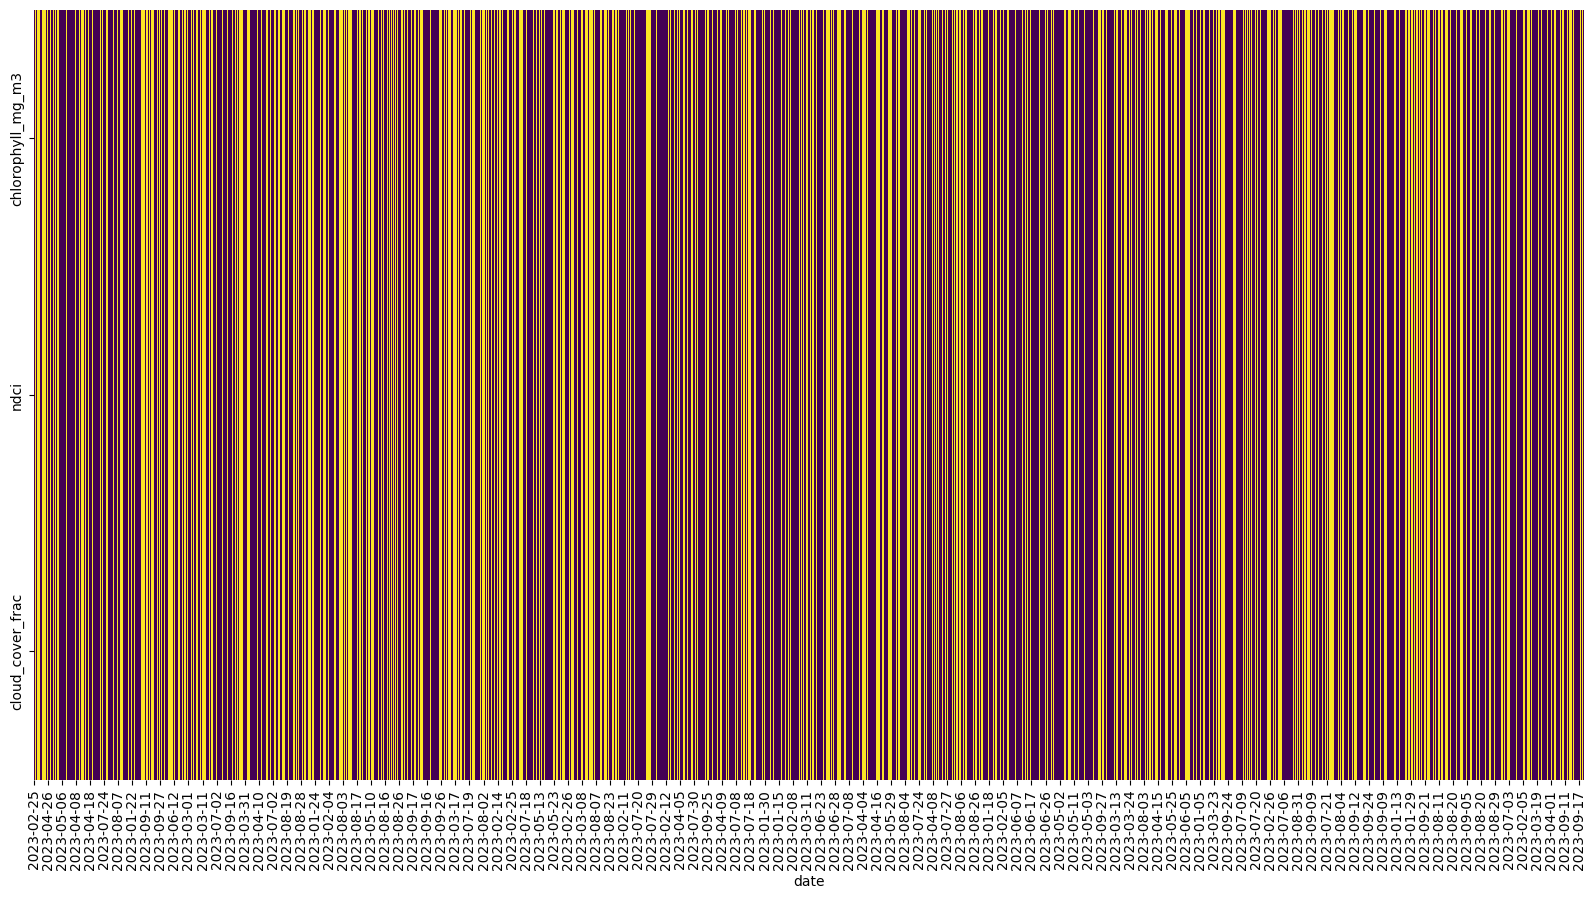

In [ ]:
plt.figure(figsize=(20,10))
data = df_train[["chlorophyll_mg_m3", "ndci", "cloud_cover_frac"]]
sns.heatmap(data.isnull().T, cbar=False, cmap='viridis' )
plt.show()

จุดสังเกตจากกราฟ
- วันที่ไม่เรียงลำดับ ทำให้ถ้าจะเติมค่าว่างตามวันมันผิด
- ทั้ง 3 columns ที่ค่าว่างหายไปตรงกันทุกวัน ดังนั้นเราจะ plot เเค่columns เดียวเพื่อให้ดูง่าย

In [ ]:
# ให้ข้อมูลเรียงตาม index
df_train =  df_train.sort_index()

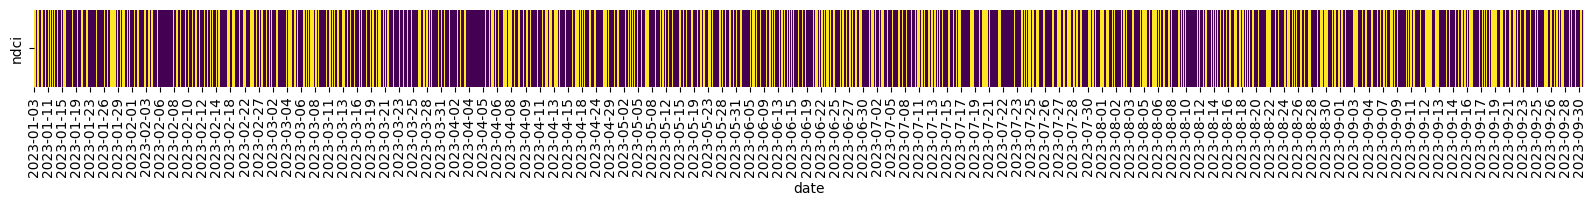

In [ ]:
plt.figure(figsize=(20,1))
sns.heatmap(df_train[["ndci"]].isnull().T, cbar = False, cmap = "viridis")
plt.show()

In [ ]:
df_train = df_train.reset_index()
df_train['date'] = pd.to_datetime(df_train['date'])

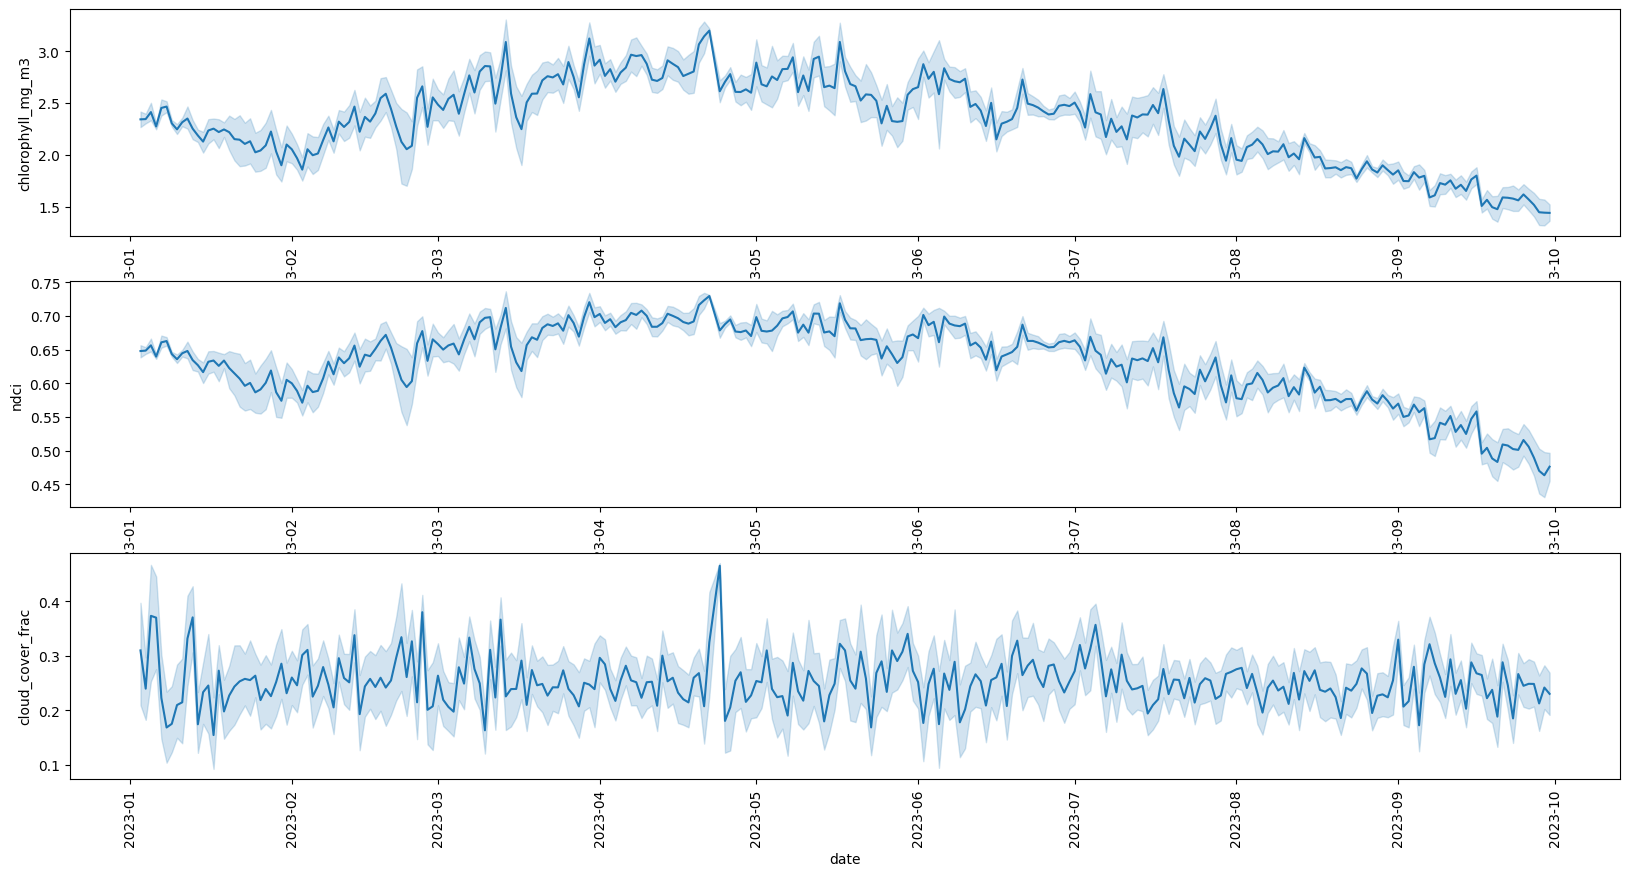

In [ ]:
columns = ["chlorophyll_mg_m3", "ndci", "cloud_cover_frac"]
plt.figure(figsize= (20,10))
for i, j in enumerate(columns):
  plt.subplot(3,1,i+1)
  sns.lineplot(data = df_train, y = j, x= "date")
  plt.xticks(rotation = 90)
plt.show()

In [ ]:
df_train["is_cloudy"] = df_train['chlorophyll_mg_m3'].isnull().astype(int)
df_test["is_cloudy"] = df_test['chlorophyll_mg_m3'].isnull().astype(int)
df_test.head(5)

/tmp/ipykernel_38381/2622430016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["is_cloudy"] = df_test['chlorophyll_mg_m3'].isnull().astype(int)


,vessel_id,mmsi,vessel_name,flag_state,vessel_type,length_m,gross_ton,timestamp,date,lat,...,sst_anomaly,chlorophyll_mg_m3,ndci,cloud_cover_frac,country_code,eez_name,zone_type,dist_to_border_nm,is_disputed,is_cloudy
1053,VSL_0003,513356886,VESSEL_6886,VNM,Trawler,17,1735,2023-10-01 00:00:00,2023-10-01,15.0242,...,-0.252,1.5149,0.5037,0.12,VNM,Vietnam_EEZ,EEZ,29.99,0,0
1054,VSL_0003,513356886,VESSEL_6886,VNM,Trawler,17,1735,2023-10-01 02:10:54,2023-10-01,15.4227,...,0.173,1.3364,0.4555,0.16,VNM,Vietnam_EEZ,EEZ,5.36,0,0
1055,VSL_0003,513356886,VESSEL_6886,VNM,Trawler,17,1735,2023-10-01 04:21:49,2023-10-01,15.5947,...,0.173,1.3364,0.4555,0.16,VNM,Vietnam_EEZ,EEZ,5.36,0,0
1056,VSL_0003,513356886,VESSEL_6886,VNM,Trawler,17,1735,2023-10-01 06:32:43,2023-10-01,15.5997,...,0.354,1.4242,0.4803,0.40,VNM,Vietnam_EEZ,EEZ,29.81,0,0
1057,VSL_0003,513356886,VESSEL_6886,VNM,Trawler,17,1735,2023-10-01 08:43:38,2023-10-01,15.4618,...,-0.000,1.3671,0.4644,0.38,VNM,Vietnam_EEZ,EEZ,45.86,0,0


เติมค่าว่างตามพื้นที่เเละเวลา
- คือการพิจารณาให้เติมค่าว่างตามพื้นที่บริเวณเดียวกันตามเวลาที่ก่อหลัง

In [ ]:
# เติมค่าตามพื้นที่เเละเวลาโดยเลือกเติมจากค่าก่อนหน้า เเละถ้าไม่เจอเอาค่าข้างหลัง
df_train['chlorophyll_mg_m3'] = df_train.groupby(['lat', 'lon'])['chlorophyll_mg_m3'].ffill().bfill()
df_train["ndci"] = df_train.groupby(["lat", "lon"])["ndci"].ffill().bfill()
df_train["cloud_cover_frac"] = df_train.groupby(["lat", "lon"])["cloud_cover_frac"].ffill().bfill()
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12356 entries, 0 to 12355
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               12356 non-null  datetime64[ns]
 1   vessel_id          12356 non-null  object        
 2   mmsi               12356 non-null  int64         
 3   vessel_name        12356 non-null  object        
 4   flag_state         12356 non-null  object        
 5   vessel_type        12356 non-null  object        
 6   length_m           12356 non-null  int64         
 7   gross_ton          12356 non-null  int64         
 8   timestamp          12356 non-null  object        
 9   lat                12356 non-null  float64       
 10  lon                12356 non-null  float64       
 11  speed_knots        12356 non-null  float64       
 12  heading_deg        12356 non-null  int64         
 13  nav_status         12356 non-null  object        
 14  ais_ga

ตรวจสอบจาก info ตอนนี้ข้อมูลเราไม่มี missing values เเลว้

### Descriptive Statistics

In [ ]:
df_train.describe()

,date,mmsi,length_m,gross_ton,lat,lon,speed_knots,heading_deg,ais_gap_hours,label_suspicious,sst_celsius,sst_anomaly,chlorophyll_mg_m3,ndci,cloud_cover_frac,dist_to_border_nm,is_disputed,is_cloudy
count,12356,1.235600e+04,12356.000000,12356.000000,12356.000000,12356.000000,12356.000000,12356.000000,12356.000000,12356.000000,12356.000000,12356.000000,12356.000000,12356.000000,12356.000000,12356.000000,12356.000000,12356.000000
mean,2023-06-04 08:24:44.752347136,5.494211e+08,62.773875,1595.392279,11.325991,108.044294,7.924885,179.872451,0.077695,0.093234,26.651191,0.133811,2.275003,0.622038,0.251725,25.482912,0.024199,0.380706
min,2023-01-03 00:00:00,5.108722e+08,16.000000,251.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,22.840000,-1.478000,0.887500,0.279300,0.000000,0.500000,0.000000,0.000000
25%,2023-03-27 00:00:00,5.267539e+08,44.000000,696.000000,5.010775,102.102750,6.130000,89.000000,0.000000,0.000000,25.790000,-0.176000,1.828400,0.570500,0.130000,13.140000,0.000000,0.000000
50%,2023-06-20 00:00:00,5.472953e+08,62.000000,1688.000000,12.477300,108.047600,8.130000,180.000000,0.000000,0.000000,26.640000,0.144000,2.269750,0.638950,0.250000,25.880000,0.000000,0.000000
75%,2023-08-11 00:00:00,5.667223e+08,87.000000,2386.000000,17.180125,114.133625,10.000000,270.000000,0.000000,0.000000,27.550000,0.448000,2.724225,0.689825,0.380000,37.762500,0.000000,1.000000
max,2023-09-30 00:00:00,5.972260e+08,113.000000,2903.000000,22.000000,122.000000,19.700000,359.000000,12.000000,1.000000,29.830000,1.775000,3.970300,0.776300,0.490000,49.990000,1.000000,1.000000
std,NaN,2.534689e+07,29.126962,858.916377,6.424546,6.913487,3.008635,104.348911,0.858665,0.290772,1.164541,0.462919,0.581959,0.086810,0.142305,14.302715,0.153672,0.485580


# EDA: Data Understanding

In [ ]:
corr_col = ['length_m', 'gross_ton', 'lat', 'lon', 'speed_knots', 'heading_deg',
       'ais_gap_hours', 'label_suspicious', 'sst_celsius', 'sst_anomaly',
       'cloud_cover_frac', 'dist_to_border_nm', "chlorophyll_mg_m3", "ndci"]

In [ ]:
corr_df = df_train[corr_col]

In [ ]:
corr = corr_df.corr()
corr

,length_m,gross_ton,lat,lon,speed_knots,heading_deg,ais_gap_hours,label_suspicious,sst_celsius,sst_anomaly,cloud_cover_frac,dist_to_border_nm,chlorophyll_mg_m3,ndci
length_m,1.000000,0.364395,-0.000678,-0.071531,0.024565,-0.001666,-0.009306,-0.045853,0.164565,0.023967,0.007972,-0.001460,0.211371,0.202788
gross_ton,0.364395,1.000000,0.033262,0.011071,0.126198,-0.000706,-0.070312,-0.237590,0.044128,-0.003743,0.007518,-0.030090,-0.017070,-0.007015
lat,-0.000678,0.033262,1.000000,0.092452,-0.015167,0.004984,0.005576,0.019125,-0.066924,0.079974,-0.004494,-0.022583,0.018704,0.052836
lon,-0.071531,0.011071,0.092452,1.000000,0.040714,0.007330,-0.026464,-0.073011,-0.001304,0.027830,-0.008930,-0.014096,-0.149147,-0.134882
speed_knots,0.024565,0.126198,-0.015167,0.040714,1.000000,0.007987,-0.163909,-0.573305,0.058172,0.015052,-0.003429,-0.031166,0.020711,0.021806
heading_deg,-0.001666,-0.000706,0.004984,0.007330,0.007987,1.000000,0.000180,-0.008701,-0.008389,0.001249,-0.000553,0.004372,-0.014129,-0.015645
ais_gap_hours,-0.009306,-0.070312,0.005576,-0.026464,-0.163909,0.000180,1.000000,0.282647,-0.035994,-0.017143,-0.007567,0.021498,-0.003384,-0.004855
label_suspicious,-0.045853,-0.237590,0.019125,-0.073011,-0.573305,-0.008701,0.282647,1.000000,-0.106091,-0.026211,-0.004135,0.046070,-0.033724,-0.038788
sst_celsius,0.164565,0.044128,-0.066924,-0.001304,0.058172,-0.008389,-0.035994,-0.106091,1.000000,0.642879,0.011152,-0.009389,0.650055,0.649064
sst_anomaly,0.023967,-0.003743,0.079974,0.027830,0.015052,0.001249,-0.017143,-0.026211,0.642879,1.000000,0.010931,-0.007114,0.329066,0.311193


<Axes: >

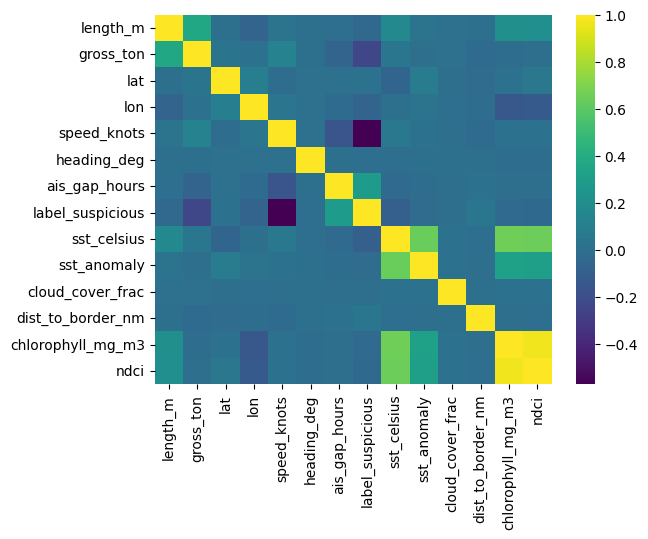

In [ ]:
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, cmap='viridis')

In [ ]:
df_train["label_suspicious"].value_counts()

,count
label_suspicious,
0,11204
1,1152


เพื่อให้เราสามารถเข้าใจได้ว่าเราจะไพเไพ่เยบลา ๆ ค่อยเขียน

## 1.) เรื่อที่น่าสงสัยส่วนใหญ่อยู่ในเขตไหน

<Axes: xlabel='zone_type', ylabel='count'>

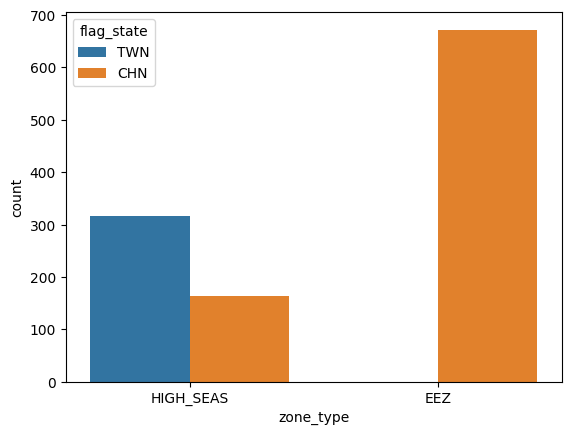

In [ ]:
sns.countplot(data = df_train[df_train["label_suspicious"]== 1],x ="zone_type", hue = "flag_state")

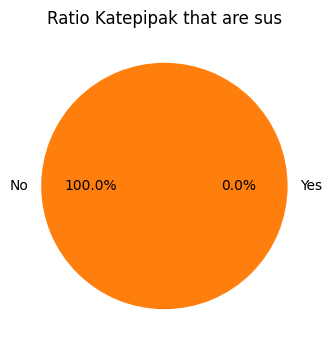

In [ ]:
df_sus = df_train[df_train["label_suspicious"] == 1]
katepipak = df_sus["is_disputed"].sum() / df_sus["is_disputed"].count()
not_katepipak = 1-katepipak
size = [katepipak, not_katepipak]
plt.figure(figsize= (4,4))
plt.pie(size, labels = ["Yes", "No"], autopct = "%1.1f%%")
plt.title("Ratio Katepipak that are sus")
plt.show()


จากทั้งสองกราฟเเสดงให้เห็นบางอย่างที่ชัดเจน(ที่ไม่คิดว่าจะเป็นเเบบนี้)
1. 100% ของเรือน่าสงสัยไม่ได้อยู่ในเขตทับซ้อนเลย(ซึ่งตอนเเรกคิดว่ามันจะอยู่เพราะกฏหมายไม่ชัดเจนจับกุมได้ยาก)

2. เป็นการจงใจรุกล้ำน่านน้ำ
การที่เรือต้องสงสัย 100% กระจุกตัวอยู่ในเขตเศรษฐกิจบ่งบอกมีความจงใจที่จะเข้ามากอบโกยทรัพยากรในพื้นที่ที่มีเจ้าของ(ประเทศจีนโดนมากที่สุด)

## 2.) วิเคราะห์ค่าค่าคลอโรฟิลล์ที่เรือพวกนี้ไปกระจุกตัว ว่าสูงผิดปกติไหม

ในเมื่อเรารู้แล้วว่าพวกเขากล้าเสี่ยงเข้ามารุกล้ำใน EEZ แบบ 100% เเล้วอะไรคือสิ่งที่ดึงดูดพวกเขาเข้ามา
- เพราะง้ั้นคำถามที่สองที่เราตั้งขึ้น สามารถดูได้ว่าสิ่งจูงใจเขาคือปลาหรือเปล่า เพราะคลอโรฟิลล์เป้นอาหารปลา

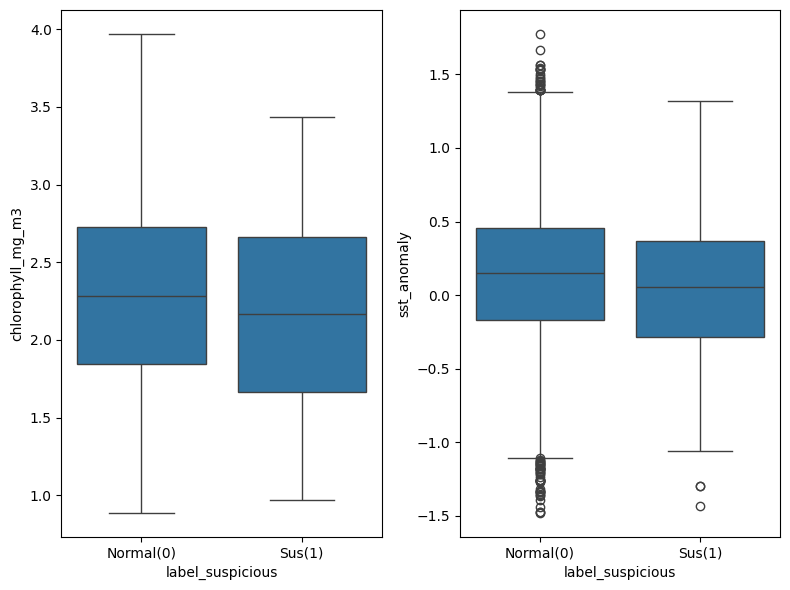

In [ ]:
plt.figure(figsize=(8, 6))

plt.subplot(1,2,1)
sns.boxplot(data=df_train, x="label_suspicious", y="chlorophyll_mg_m3")
plt.xticks([0, 1], ['Normal(0)', 'Sus(1)'])

plt.subplot(1,2,2)
sns.boxplot(data=df_train, x="label_suspicious", y="sst_anomaly")
plt.xticks([0, 1], ['Normal(0)', 'Sus(1)'])
plt.tight_layout()
plt.show()

จากกราฟการที่กล่องของทั้งสองกลุ่มเเทบจะทับซ้อนกันเลยมันหมายความว่า
1. คลอโรฟิลล์อย่างเดียวไม่ใช่ตัวแบ่งแยกที่ชัดเจน ซึ่งไม่เเปลกเพราะในความเป็นจริง ไม่ว่าจะเป็นเรือประมงถูกกฎหมายหรือผิดกฎหมาย ต่างก็ต้องวิ่งไปหาจุดที่มีปลาเหมือนกัน

## 3.) วิเคราะห์การปิดสัญญาณ AIS

เนื่องจากคนทำผิดกฏหมายไม่ได้เข้ามาเพราะมีเเหล่งอาหารเยอะเพียงอย่างเดียวงั้นเราเราจะมาดูกันว่า ตอนที่มันข้ามเส้นเข้ามาใน EEZ มันจงใจปิดสัญญาณ AIS เพื่อพรางไหม

<Figure size 400x400 with 0 Axes>

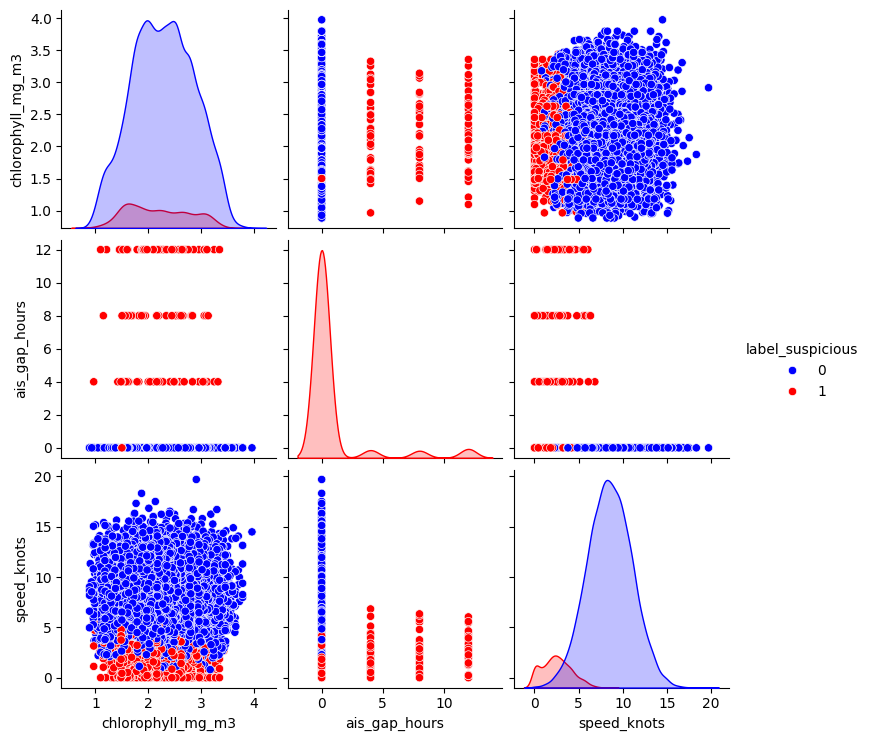

In [ ]:
col = ['chlorophyll_mg_m3', 'ais_gap_hours', 'speed_knots', 'label_suspicious']
plt.figure(figsize=(4,4))
sns.pairplot(df_train[col], hue='label_suspicious', palette={0: 'blue', 1: 'red'})
plt.show()

1. เรือเเอบปิดสัญญาณทำไรกัน

    กราฟแนวทแยงตรงกลาง
    
    เรือปกติ(น้ำเงิน): จุดกองรวมกันที่เลข 0 แบบ 100% แปลว่าเรือปกติแทบจะไม่เคยเปิด ๆ ปิด ๆ สัญญาณ AIS เลย

    เรือต้องสงสัย(แดง):เห็นได้ชัดเลยว่ามีเเอบปิดสัญญาณ (ถ้าดูกราฟ scatter ของ ais_gap_hour vs chlorophyll เห็นชัดเจนเลยว่ามีการปิดสัญญาณ)

    สรุป: เรือกลุ่มนี้จงใจปิดสัญญาณเป็นกะ (เช่น ปิดทีละ 4 ชม. หรือ 8 ชม. เพื่อแอบทำอะไรบางอย่างแล้วค่อยเปิดใหม่)

2. ชะลอความเร็วเพื่อหาปลา

    กราฟแนวทแยงมุมขวาล่าง

    เรือปกติ(น้ำเงิน): สูงมากอยู่ที่ความเร็วประมาณ 8-12 Knots (ความเร็วเดินทางปกติของเรือสินค้าหรือเรือที่กำลังแล่นผ่าน)

    เรือต้องสงสัย(แดง): ความเร็ว 0 ถึง 4 Knots เอง

    สรุป: ความเร็วระดับ 1-4 Knots ไม่ใช่การแล่นเรือปกติ แต่คือความเร็วของการหย่อนอวนหรือลากอวนจับปลา

3. เเล้วคลอโรฟิลล์ (อาหารปลา) สำคัญไหม

    กราฟคอลัมน์ซ้ายสุด

    เราจะเห็นว่าจุดสีแดงกระจายตัวตั้งแต่ค่าคลอโรฟิลล์ 1.0 ไปจนถึง 3.5 แปลว่า เรือไม่ได้เล็งเฉพาะจุดที่คลอโรฟิลล์สูงปรี๊ดที่สุดเท่านั้น แต่มันหากินในบริเวณกว้างๆ ที่มีอาหารปลาอยู่

    สรุป: คลอโรฟิลล์อาจจะไม่ได้ช่วยจับเรื่องเรือน่าสงสัยขนาดนั้น

# Data Preparation

## Feature Engineering

สรุปข้อมูลทั้งหมดจากการ EDA
1. พื้นที่: ไม่สนเขตพิพาท มุ่งเป้าเจาะเข้าเขตเศรษฐกิจจำเพาะ
2. พฤติกรรม: แล่นเข้ามาในเขตอาหารปลาด้วยความเร็วลากอวนต่ำ (0-4 Knots) และจงใจปิดสัญญาณ AIS เป็นกะ (4, 8 ชั่วโมง) เพื่อหลบการตรวจ


เราจะเอา insight ที่เราได้ทั้งหมดมาสอนให้โมเดลรู้จัก เพราะงั้นเราจะสร้างคอลัมน์ใหม่ ให้โมเดลใช้เป็นทางลัดในการตัดสินใจ
เเต่จะตั้งเงื่อนไขเเบบ generalization เพื่อไม่ให้เป็นการล็อกมงคำตอบเเค่ปี 2023 ที่เราได้ EDA ดูไป

In [ ]:
df_train_fe = df_train.copy()
df_test_fe = df_test.copy()

In [ ]:
df_train_fe["train"] = 1
df_test_fe["train"] = 0

In [ ]:
df_ALL_fe = pd.concat([df_train_fe, df_test_fe])

### 1. การปิดสัญญาณ


Fact ถ้าเรือไม่ได้ทำผิดกฏหมายอะไรไม่จำเป็นต้องปิดสัญญาณ AIS อันนี้ข้อเท็จจริงไม่ใช่ข้อมูลบังเอิญ ใช้ได้ทุกปั


In [ ]:
df_ALL_fe["is_turnoff_AIS"] = (df_ALL_fe["ais_gap_hours"] > 0).astype(int)
df_ALL_fe[["is_turnoff_AIS", "ais_gap_hours"]].sample(5)

,is_turnoff_AIS,ais_gap_hours
11060,0,0
6650,0,0
6494,0,0
8982,0,0
1269,0,0


### 2. ความเร็วเรือ

ถ้าความเร็วอยู่ระหว่าง 0 - 4 Knots อันนี้ก็ใช้ได้ตลอด เพราะความเร็วลากอวนมันก็เท่านี้

In [ ]:
df_ALL_fe["is_sus_speed"] = (df_ALL_fe["speed_knots"] <5).astype(int)
df_ALL_fe[["is_sus_speed", "speed_knots"]].sample(5)

,is_sus_speed,speed_knots
3263,0,5.64
8007,0,9.79
7336,0,9.37
4877,0,6.62
14938,0,12.17


### 3. สกัดเอาเวลา, เดือน

In [ ]:
df_ALL_fe['date'] = pd.to_datetime(df_ALL_fe['date'], format='%Y-%m-%d')
df_ALL_fe["month"] = df_ALL_fe["date"].dt.month
df_ALL_fe["hour"] = df_ALL_fe["date"].dt.hour

In [ ]:
df_ALL_fe.columns

Index(['date', 'vessel_id', 'mmsi', 'vessel_name', 'flag_state', 'vessel_type',
       'length_m', 'gross_ton', 'timestamp', 'lat', 'lon', 'speed_knots',
       'heading_deg', 'nav_status', 'ais_gap_hours', 'label_suspicious',
       'sst_celsius', 'sst_anomaly', 'chlorophyll_mg_m3', 'ndci',
       'cloud_cover_frac', 'country_code', 'eez_name', 'zone_type',
       'dist_to_border_nm', 'is_disputed', 'is_cloudy', 'train',
       'is_turnoff_AIS', 'is_sus_speed', 'month', 'hour'],
      dtype='object')

### 4. ตัด columns ที่ไม่จำเป็น

In [ ]:
df_ALL_fe = df_ALL_fe.drop(["date", "timestamp", "vessel_id", "mmsi", "vessel_name", "eez_name", "country_code", "chlorophyll_mg_m3", "ndci"], axis = 1)
df_ALL_fe.columns

Index(['flag_state', 'vessel_type', 'length_m', 'gross_ton', 'lat', 'lon',
       'speed_knots', 'heading_deg', 'nav_status', 'ais_gap_hours',
       'label_suspicious', 'sst_celsius', 'sst_anomaly', 'cloud_cover_frac',
       'zone_type', 'dist_to_border_nm', 'is_disputed', 'is_cloudy', 'train',
       'is_turnoff_AIS', 'is_sus_speed', 'month', 'hour'],
      dtype='object')

## One-Hot Encoding

In [ ]:
df_ALL_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15862 entries, 0 to 15861
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   flag_state         15862 non-null  category
 1   vessel_type        15862 non-null  category
 2   length_m           15862 non-null  int64   
 3   gross_ton          15862 non-null  int64   
 4   lat                15862 non-null  float64 
 5   lon                15862 non-null  float64 
 6   speed_knots        15862 non-null  float64 
 7   heading_deg        15862 non-null  int64   
 8   nav_status         15862 non-null  category
 9   ais_gap_hours      15862 non-null  int64   
 10  label_suspicious   15862 non-null  int64   
 11  sst_celsius        15862 non-null  float64 
 12  sst_anomaly        15862 non-null  float64 
 13  cloud_cover_frac   14487 non-null  float64 
 14  zone_type          15862 non-null  category
 15  dist_to_border_nm  15862 non-null  float64 
 16  is_disput

In [ ]:
cat_col = ['vessel_type', 'nav_status', 'zone_type']
df_ALL_fe[cat_col].nunique()

,0
flag_state,10
vessel_type,6
nav_status,4
zone_type,3


In [ ]:
df_ALL_fe[cat_col] = df_ALL_fe[cat_col].astype('category')

In [ ]:
df_dummy = pd.get_dummies(df_ALL_fe, dtype=int)
df_dummy.head()

,length_m,gross_ton,lat,lon,speed_knots,heading_deg,ais_gap_hours,label_suspicious,sst_celsius,sst_anomaly,...,vessel_type_Reefer,vessel_type_Squid_Jigger,vessel_type_Trawler,nav_status_Fishing,nav_status_Moored,nav_status_Underway,nav_status_Unknown,zone_type_DISPUTED,zone_type_EEZ,zone_type_HIGH_SEAS
0,82,252,18.2490,100.3644,7.67,24,0,0,24.34,-0.307,...,0,0,1,0,0,1,0,0,0,1
1,82,252,18.2176,100.6478,9.77,23,0,0,24.52,-0.128,...,0,0,1,1,0,0,0,0,0,1
2,82,252,18.2699,100.5321,10.72,31,0,0,24.06,-0.595,...,0,0,1,0,0,1,0,0,0,1
3,82,252,17.8364,100.8734,6.37,108,0,0,23.84,-0.959,...,0,0,1,1,0,0,0,0,0,1
4,82,252,18.1283,100.9778,4.45,318,0,0,24.28,-0.375,...,0,0,1,0,0,1,0,0,0,1


In [ ]:
df_train = df_dummy[df_dummy["train"] == 1]
df_test = df_dummy[df_dummy["train"] == 0]
print(df_train.shape)
print(df_test.shape)

(12356, 42)
(3506, 42)


# Modeling

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

scale_weight = 10

models = {
    "Logistic Regression (Balanced)": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),

    "Random Forest (Balanced)": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),

    "XGBoost (Weighted)": XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_weight, random_state=42)
}

tscv = TimeSeriesSplit(n_splits=5)

X = df_train.drop(columns=['label_suspicious'])
y = df_train['label_suspicious']

results = []
for name, model in models.items():
    # ใช้ f1-score หรือ precision/recall เพราะข้อมูลเราไม่สมดุล (Imbalanced)
    cv_results = cross_validate(model, X, y, cv=tscv, scoring=['f1', 'precision', 'recall'])

    results.append({
        "Model": name,
        "F1-Mean": cv_results['test_f1'].mean(),
        "Precision-Mean": cv_results['test_precision'].mean(),
        "Recall-Mean": cv_results['test_recall'].mean()
    })

results_df = pd.DataFrame(results)
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

                            Model   F1-Mean  Precision-Mean  Recall-Mean
0  Logistic Regression (Balanced)  0.618873        0.548637     0.780467
1        Random Forest (Balanced)  0.472502        0.559322     0.422168
2              XGBoost (Weighted)  0.440840        0.431548     0.477890


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:21:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. ประกาศตัวแปรแชมป์เปี้ยนของเรา
final_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# 2. แยก X (Features) และ y (เฉลย) ของ Train Set
X_train = df_train.drop(columns=['label_suspicious'])
y_train = df_train['label_suspicious']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. ดึงชื่อคอลัมน์และค่าน้ำหนัก (Coefficients) ออกมาจากโมเดล
feature_names = X_train.columns
coefficients = final_model.coef_[0]

# 2. สร้าง DataFrame เพื่อให้ดูง่ายขึ้น
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

# 3. เรียงลำดับจากค่าบวกมากสุด (ผลักให้เป็นโจร) ไปค่าลบสุด (ผลักให้เป็นคนดี)
feature_importance = feature_importance.sort_values(by='Importance', key=abs, ascending=False)

# 4. พล็อตกราฟโชว์ Top 15 ฟีเจอร์ที่โมเดลให้ความสำคัญ
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='vlag')
plt.title('Top 15 Feature Importances (Logistic Regression)')
plt.xlabel('Coefficient Value (Weight)')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

# แอบดูคะแนนของคลอโรฟิลล์โดยเฉพาะ
chloro_score = feature_importance[feature_importance['Feature'] == 'chlorophyll_mg_m3']['Importance'].values
if len(chloro_score) > 0:
    print(f"\nค่าน้ำหนักของ Chlorophyll: {chloro_score[0]:.4f}")

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

- ครั้งเเรกใส่ข้อมูลทุก columns เลย == recall 78, precision 53
- ครั้งที่สองเอา chlorophyll ndci ออก == recall 78, precision 54

# For more policy

## 1.) วิเคราะห์ว่ามีช่วงไหนที่เรือเถื่อนเยอะ

ลองถ้ามีข้อมูลมากกว่า 1 ปีน่าจะวิเคราะห์ได้เเต่อันนี้ลองดูเเนวโน้มเเค่ปี 2023 ก่อนว่ามีอะไรน่าสนใจบ้าง

จากสามข้อบนเราได้รู้เรื่องของ สถานที่เกิดเหตุ เเละพฤติกรรมเเล้ว ทีนี้เรามาดูเรื่องของเวลาบ้างว่ามีช่วงไหนที่เกิดการทำประมงผิดดฎหมายเเบบเกาะกลุ่มหรือป่าว


In [ ]:
# เอาเดือนเพราะเราจะได้รุ้ว่าเดือนไหนเกิดเหตุบ่อย
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df.sample()

,vessel_id,mmsi,vessel_name,flag_state,vessel_type,length_m,gross_ton,timestamp,date,lat,...,sst_anomaly,chlorophyll_mg_m3,ndci,cloud_cover_frac,country_code,eez_name,zone_type,dist_to_border_nm,is_disputed,month
12560,VSL_0049,526753883,VESSEL_3883,CHN,Squid_Jigger,87,1197,2023-08-27 00:00:00,2023-08-27,2.5438,...,-0.542,1.833,0.5714,0.11,MYS,Malaysia_EEZ,EEZ,13.43,0,8


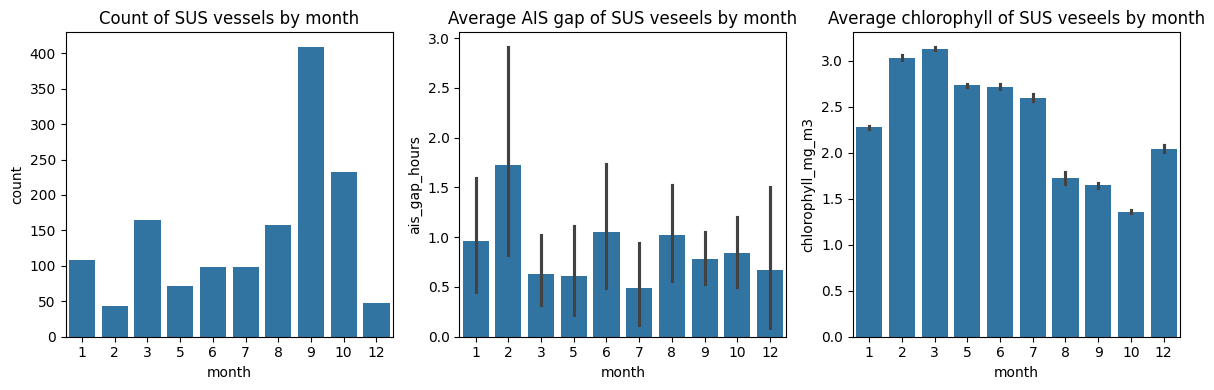

In [ ]:
df_sus = df[df["label_suspicious"] == 1]
plt.figure(figsize= (12, 4))
plt.subplot(1,3,1)
sns.countplot(data = df_sus, x = "month")
plt.title("Count of SUS vessels by month")

plt.subplot(1,3,2)
sns.barplot(data = df_sus, x = "month", y = 'ais_gap_hours')
plt.title("Average AIS gap of SUS veseels by month")

plt.subplot(1,3,3)
sns.barplot(data = df_sus, x = "month", y = "chlorophyll_mg_m3")
plt.title("Average chlorophyll of SUS veseels by month")
plt.tight_layout()
plt.show()

จากกราฟมีเรื่องน่าสนใจอยู่อย่างคือ
- เดือน 4 ไปไหน หรือมันไม่มีตั้งเเต่เเรกต้องลองตรวจ

In [ ]:
print("All veseels")
print(df_train["month"].unique())
print("-"*10)
print("SUS veseels")
df_sus["month"].unique()

All veseels
[1 2 3 4 5 6 7 8 9]
----------
SUS veseels


array([ 2,  3,  1, 10, 12,  5,  6,  8,  7,  9], dtype=int32)

จากการตรวจสอบพบว่ามีเดือนครบทั้ง 12 เดือนนั่นหมายความว่าสองเดือนนี้อาจมีเรื่องที่ทำให้ไม่สามารถเข้ามาทำผิดกฏหมายได้

สรุปข้อมูลจากกราฟเเละเรื่องเดือนหาย
1. เรือน่าสงสัยหายไป
    
    - เดือน 4 และ 11 หายไปจากกราฟทั้ง 3 แบบ
    - ไม่ได้เกิดจากการที่ device เสียหายในช่วงนั้น เพราะเรือปกติก็มี records เก็บไว้ เเต่เป็นการ ตั้งใจหลบหลีกอย่างเป็นระบบ --> ต้องไปหาข้อมูลเพิ่มว่าเดือน 4, 11 มีอะไรซึ่งอันนี้ไม่รุ้เพราะงั้นจะตั้งเป็นสมมติฐานเบื้องต้นไปก่อน
    * เดือน 4(เมษา): หลบกฎหมายและเจ้าหน้าที่ (ช่วงปิดอ่าว/ลาดตระเวนเข้มงวดป้องกันปลาที่ไข่) [Department of Fisheries, Thailand]
    - เดือน 11(พฤศจิกา): หลบภัยธรรมชาติ (ช่วงมรสุม คลื่นลมแรงจนเรือประมงเล็กถึงกลางออกทะเลไม่ได้ เเต่เรือสินค้าใหญ่ ๆ ยังวิ่งได้ปกติ) [Thai Meteorological Department) | WMO]
    - สรุปว่าเรือที่น่าสงสับรู้ว่าช่วงไหนควรไม่ควรเข้าไป

2. เดือน 9 เเปก

    - กราฟซ้ายสุด: เดือน 9 มีเรือต้องสงสัยมาเยอะที่สุด (400 ลำเลยหละ)
    - กราฟขวาสุด: แต่ค่าเฉลี่ยคลอโรฟิลล์ในเดือน 9 กลับต่ำ (ประมาณ 1.6-1.7) เมื่อเทียบกับช่วงต้นปีซึ่งก็ตรงกับที่เราเคยหาว่าคลอโนฟิลมันไม่สอดคล้องกับจำนวนเรือน่าสงสัย เเล้วมากันทำไม
    - อาจเป้นเพราะเดือน 9 คือ หลังมรสุม/หลังเปิดอ่าว เสี้ยอยากหาเงิน หรืออาจจะมี Time Lag (อาหารปลาเยอะช่วงเดือน 6-7 โตกลายเป็นปลาใหญ่ให้จับได้ในเดือน 9)  

3. เดือน 2 สยองขวัญ
    - กราฟซ้ายสุด: เดือน 2 มีเรือกลุ่มน้อยมาก (ไม่ถึง 50 ลำ)
    - กราฟตรงกลาง: แต่ระยะเวลาแอบปิดสัญญาณ AIS กลับนานที่สุด แถมมีค่าความแกว่งตัวสูงมาก
    - กราฟขวาสุด: เป็นช่วงที่คลอโรฟิลล์อุดมสมบูรณ์สูง (เกือบ 3.0)
    - เดือน 2 คือช่วงที่อาหารสมบูรณ์สุด ๆ แต่แทนที่จะแห่กันมาเยอะ ๆ กลับมีเรือแค่กลุ่มเล็ก ๆ ที่กล้าเข้ามา แถมมาแล้วก็จงใจปิดสัญญาณหนีการตามรอยเเบบไม่เเคร์
    - อาจจะเป็นพฤติกรรมของเรือประมงเถื่อนมืออาชีพ ที่รุ้เเหล้งเเละรุ้ว่าต้องเก็บเงียบ --> สมมติฐาน

## 2.) วิเคราะห์ผู้ร้ายตัวจริง

เรือที่แอบเข้ามาทำผิดกฎหมาย มักจะเป็นเรือประเภทไหน สัญชาติอะไร และมีขนาดใหญ่หรือเล็ก จะไ้ดรุ้ว่าควรกำหนดนโยบายเฝ้าระวังเรืออะไรเป็นพิเศษ

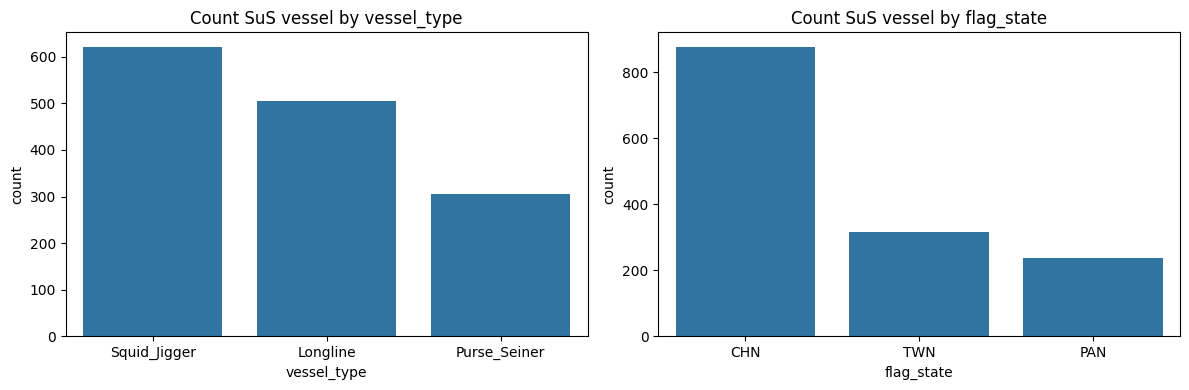

In [ ]:
# ดูว่าเรือเถือนอยู่ที่ไหนเเละเป็นเรือประเภทอะไรบ้าง
col = ["vessel_type", "flag_state"]
df_sus = df[df["label_suspicious"] == 1]
plt.figure(figsize = (12,4))
for i,j in enumerate(col):
  plt.subplot(1,2,i+1)
  sns.countplot(data = df_sus, x=j, order = df_sus[j].value_counts().index)
  plt.title(f"Count SuS vessel by {j}")
plt.tight_layout()
plt.show()

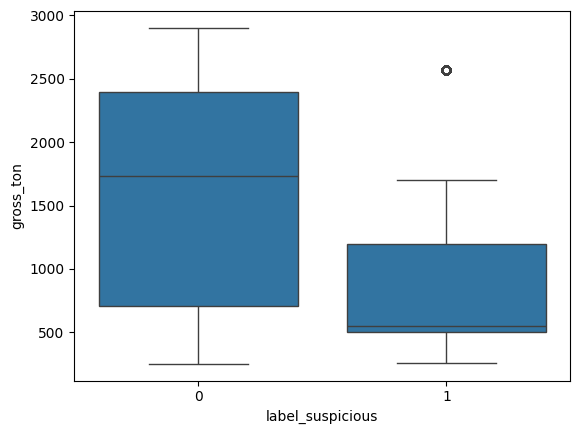

In [ ]:
# ขนาดของเรือเทียบระหว่างเรือปกติกับเรือเถื่อน
sns.boxplot(data=df, x='label_suspicious', y='gross_ton')
plt.show()

จากทั้งสองรูปสรุปได้ว่า
1. สัญชาติ
  - จีนเป็นส่วนมากเลยที่เถื่อนทำไมจีน --> จีนมีกองเรือประมงน้ำลึก ที่ใหญ่ที่สุดในโลก และมักจะเดินทางไปจับปลาข้ามทวีป
2. ประเภทเรือ
  - เรือตกหมึกและเบ็ดราว เรือตกหมึกมักจะทำงานตอนกลางคืนโดยใช้ไฟล่อ กับเรือเบ็ดราวเป็นเรือที่จับปลาทูน่าหรือปลาผิวน้ำที่มีมูลค่าสูง

3. ขนาดเรือ
  - อันนี้ค่อยเห็นชัดหน่อย เรือเถื่อนส่วนมากเล็ก เนื่องจากขนาดเรือกระจุกตัวอยู่ที่ประมาณ 500-1,200 ตันเป็นไซส์มาตรฐานของเรือประมงพาณิชย์ข้ามชาติ